# Quantification of Mitochondria in 2D Fluorescent Stacks
- *Isobel Taylor-Hearn, 2023*
- Requires a fluorescent image stack containing (at least) a nuclear channel and mitochondria channel

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math
from cellpose import models
import os
import pathlib
from collections import Counter
from skimage.segmentation import find_boundaries
from liffile import LifFile
from skimage.feature import peak_local_max
from skimage import util,  restoration
from skimage.filters import threshold_otsu, threshold_isodata, threshold_mean, gaussian, threshold_yen
from skimage.segmentation import clear_border, expand_labels, watershed
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  disk, dilation
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from tifffile import imread
from skimage.filters import try_all_threshold

import warnings
warnings.filterwarnings("ignore")
import pathlib

import contextlib
import joblib
from tqdm import tqdm
from joblib import Parallel, delayed

In [2]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.

    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [3]:
def convert(img, target_type_min, target_type_max, target_type):
    """
    Converts an image to a specified data type while scaling its intensity values.

    This function rescales the intensity values of an image from its original range 
    to a new target range specified by `target_type_min` and `target_type_max`, and 
    then converts it to the desired data type.

    This step is required as deconvolved images are not always scaled 0->255! 

    Parameters:
    -----------
    img : numpy.ndarray
        The input image array to be converted.
    target_type_min : int or float
        The minimum value of the target intensity range.
    target_type_max : int or float
        The maximum value of the target intensity range.
    target_type : numpy.dtype
        The desired data type of the output image (e.g., np.uint8, np.float32).

    Returns:
    --------
    new_img : numpy.ndarray
        The rescaled image with values mapped to the new intensity range and converted 
        to the specified data type.

    Notes:
    ------
    - This function performs a linear transformation to scale pixel values.
    - It ensures that the output values are properly mapped between `target_type_min` and 
      `target_type_max`.
    """
    imin = img.min()
    imax = img.max()

    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [4]:
def add_image_details(df, filename):
    """
    Adds experimental details extracted from the filename to a dataframe.

    This function parses the filename to infer experimental details such as 
    well number, imaging day, mechanical stiffness condition, and treatment type.
    The extracted details are appended as new columns to the dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to which image metadata will be added.
    filename : str
        The filename of the image, used to extract experimental details.

    Returns:
    --------
    df : pandas.DataFrame
        The updated dataframe with the following added columns:
        - 'filename': The original filename.
        - 'cell_type': L_LNS or M_LNS
        - 'treatment': Blebbistatin, ROCKi, or untreated
        - 'timepoint': 0hr, 1hr, or 24hr
    """

    df["filename"] = filename
    test_filename = str(filename).lower()
    if "e2p4" in test_filename and "tnf" in test_filename and "fulv" in test_filename:
        df["treatment"] = "E2P4_TNF_FULV" 
        
    elif "e2p4" in test_filename and "tnf" in test_filename:
        df["treatment"] = "E2P4_TNF"
    elif "fulv" in test_filename and  "tnf" in test_filename:
        df["treatment"] = "FULV_TNF"
        
    elif "ctrl" in test_filename:
        df["treatment"] = "NONE"
    elif "ep24" in test_filename:
        df["treatment"] = "E2P4"  
    elif "tnf" in test_filename:
        df["treatment"] = "TNF"

    else:
        df["treatment"] = "UNKNOWN!"  


    return df

In [5]:
def segment_nuclei(dapi, protein_of_interest_1, protein_of_interest_2):
    """
    Segment cells and nuclei with Cellpose.

    Cells are segmented from a 2-channel image: a fused cell body = max(phalloidin, ICAM1)
    (both fill the cytoplasm) plus DAPI, which lets Cellpose use the nuclei to split
    touching cells. Nuclei are segmented separately from DAPI by thresholding + watershed.

    Parameters
    ----------
    dapi : ndarray
        Nuclear (DAPI) image.
    protein_of_interest_1 : ndarray
        ICAM1 image (cytoplasmic).
    protein_of_interest_2 : ndarray
        Phalloidin (F-actin) image - edges + cytoplasm.

    Returns
    -------
    dapi_labels : ndarray (int)
        Segmented nuclei.
    all_cells : ndarray (int)
        Segmented cells.
    """
    model = models.CellposeModel(gpu=True, pretrained_model="cpsam_v2")

    def _n(a):
        a = a.astype(np.float32)
        p1, p2 = np.percentile(a, [1, 99.7])
        return np.clip((a - p1) / (p2 - p1), 0, 1) if p2 > p1 else np.zeros_like(a)

    body = np.maximum(_n(protein_of_interest_2), _n(protein_of_interest_1))  # phalloidin + ICAM1 fill the cell
    cell_input = np.stack([body, _n(dapi)], axis=-1)   # [cell body, DAPI]
    all_cells, _, _ = model.eval(cell_input, channel_axis=-1, normalize=True,
                                 min_size=50, flow_threshold=0.6, cellprob_threshold=-4.0)
    all_cells = np.asarray(all_cells)

    # Nuclei from the DAPI channel (thresholding works well here).
    dapi_processed = dapi > threshold_yen(dapi)
    dapi_processed = remove_small_holes(dapi_processed, area_threshold=20)
    dapi_processed = remove_small_objects(dapi_processed, min_size=50)
    dapi_labels = label(dapi_processed)
    distances = ndi.distance_transform_edt(dapi_processed)
    coordinates = peak_local_max(distances, min_distance=10)  # min separation of nuclear COMs
    marker_locations = coordinates.data
    markers = np.zeros(dapi_processed.shape, dtype=np.uint32)
    marker_indices = tuple(np.round(marker_locations).astype(int).T)
    markers[marker_indices] = np.arange(len(marker_locations)) + 1

    dapi_labels_ws = watershed(-distances, markers, mask=dapi_processed)
    dapi_labels = label(dapi_labels_ws + dapi_labels)

    return dapi_labels, all_cells

In [6]:

def lif_pixel_sizes(img):
    """Return (z_um, y_um, x_um) from a liffile image; any value is None if unavailable."""
    z_um = y_um = x_um = None
    try:
        coords = img.asxarray().coords
        if "X" in coords and coords["X"].size >= 2:
            x_um = abs(float(coords["X"][1] - coords["X"][0])) * 1e6
        if "Y" in coords and coords["Y"].size >= 2:
            y_um = abs(float(coords["Y"][1] - coords["Y"][0])) * 1e6
        if "Z" in coords and coords["Z"].size >= 2:
            z_um = abs(float(coords["Z"][1] - coords["Z"][0])) * 1e6
    except Exception as e:
        print(f"  [WARN] could not read LIF pixel sizes: {e}")
    return z_um, y_um, x_um

In [7]:
import numpy as np

from scipy import ndimage as ndi
from skimage import exposure
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes


def preprocess_dim_fluorescence(
    image,
    background_sigma=10,
    denoise_sigma=1,
    low_percentile=1,
    high_percentile=99.8,
):
    """
    Preprocess a dim fluorescence image for classical thresholding.
    """

    img = image.astype(np.float32)

    # ---------------------------------------------------------
    # 1. Estimate slowly varying background
    # ---------------------------------------------------------
    background = ndi.gaussian_filter(
        img,
        sigma=background_sigma
    )

    img_corrected = img - background
    img_corrected[img_corrected < 0] = 0

    # ---------------------------------------------------------
    # 2. Mild denoising
    # ---------------------------------------------------------
    img_smooth = ndi.gaussian_filter(
        img_corrected,
        sigma=denoise_sigma
    )

    # ---------------------------------------------------------
    # 3. Robust contrast stretching
    # ---------------------------------------------------------
    p_low, p_high = np.percentile(
        img_smooth,
        [low_percentile, high_percentile]
    )

    img_rescaled = exposure.rescale_intensity(
        img_smooth,
        in_range=(p_low, p_high),
        out_range=(0, 1),
    )

    return img_rescaled

In [8]:
def segment_nuclei_and_quantify_protein(input_directory,  output_dir , to_plot = True, membrane_channel=None, dapi_channel = 0, protein_of_interest_1_name="ICAM1", protein_of_interest_1_channel = 1, protein_of_interest_2_name=None, protein_of_interest_2_channel = None, pixel_size = 7.4627, max_proj = False):
    """
    Segment cells + nuclei from a multi-channel image and quantify a protein of interest per cell.

    Cells and nuclei are segmented with Cellpose (see segment_nuclei) and paired 1:1. Only
    cells in 1:1 agreement with a nucleus and NOT touching the field-of-view (FOV) border are
    measured. The FOV occupancy, however, is computed from ALL cells (border-touching included).

    Returns
    -------
    all_props : pandas.DataFrame
        One row per measured cell, including:
        - 'filename', 'treatment'
        - 'label'
        - 'cell_area_um2'      : cell area in square microns
        - 'nuclear_area_um2'   : nucleus area in square microns
        - 'nuc/cell_area'      : nuclear / cell area ratio
        - 'fov_unoccupied_pct' : % of the FOV NOT covered by any cell (per image, border cells included)
        - '{protein}_cell', '{protein}_nucleus', '{protein}_nucleus/cell' intensity measures
    """
    all_props = []

    for lif_path in sorted(input_directory.rglob("*.lif")):
        print(f"LIF: {lif_path}")
        with LifFile(lif_path) as lif:
            for i, img in enumerate(lif.images):
                if i < 5:
                    sub_name = "".join(img.path)
                    data = img.asarray()
                    print(data.shape)
                    z_um, y_um, x_um = lif_pixel_sizes(img)
                    filename = f"{lif_path.stem}_{sub_name}".replace(" ", "")
                    print(filename, data.shape, (z_um, y_um, x_um))

                    if max_proj == True:
                        dapi = convert(data[:,dapi_channel, :, :].sum(axis=0), 0, 255, np.uint8)
                        # dapi = np.clip(dapi, a_min=0, a_max=40)
                        protein_of_interest_1 = convert(data[:,protein_of_interest_1_channel, :, :].sum(axis=0), 0, 255, np.uint8)
                    else:
                        dapi = convert(data[:,dapi_channel, :, :], 0, 255, np.uint8)
                        protein_of_interest_1 = convert(data[:,protein_of_interest_1_channel, :, :], 0, 255, np.uint8)

                    if membrane_channel is not None:
                        if max_proj == True:
                            membrane = convert(data[:,membrane_channel, :, :].max(axis=0), 0, 100, np.uint8)
                            # membrane = np.clip(membrane, a_min = 0, a_max = 80)
                        else:
                            membrane = convert(data[:,membrane_channel, :, :].max(axis=0), 0, 255, np.uint8)
                        

                        
                    dapi_out = preprocess_dim_fluorescence(dapi)
                    membrane_out = preprocess_dim_fluorescence(membrane)
        
                    
                    if protein_of_interest_2_channel is not None:
                        if max_proj == True:
                            protein_of_interest_2 = convert(data[protein_of_interest_2_channel, :, :].max(axis=0), 0, 255, np.uint8)
                        else:
                            protein_of_interest_2 = convert(data[protein_of_interest_2_channel, :, :], 0, 255, np.uint8)
                        rgb_image = np.stack([protein_of_interest_1, protein_of_interest_2, dapi_out], axis=-1)
                    elif membrane_channel is not None:
                        # rgb_image = np.stack([protein_of_interest_1, membrane_out, dapi_out], axis=-1)
                        rgb_image = np.stack([np.zeros_like(dapi), membrane_out, dapi_out], axis=-1)

                    else:
                        rgb_image = np.stack([protein_of_interest_1, membrane_out, dapi], axis=-1)
                        
                    # Physical area per pixel (fall back to square pixels if only one size known).
                    pixel_area_um2 = (x_um * y_um) if (x_um and y_um) else (pixel_size ** 2)

                    dapi_labels, cell_labels = segment_nuclei(dapi_out, protein_of_interest_1, protein_of_interest_2)
                    
                    
                    total_signal = gaussian(np.mean(rgb_image, axis=-1),sigma=2)
                    cells = total_signal > threshold_mean(total_signal)
                    total_cell_region = cells | (cell_labels > 0)                    
                    gaps = ~total_cell_region
                    
                    

                    # % of FOV not covered by ANY cell (border-touching cells included).
                    # fov_unoccupied_pct = 100.0 * (all_cells == 0).sum() / all_cells.size

                    # Per-cell measurements: only the 1:1, non-border cells.
                    # cell_props = pd.DataFrame(
                    #     regionprops_table(cell_labels, properties=("label", "area"))
                    # ).rename(columns={"area": "cell_area_pixel"})
                    # nuclear_props = pd.DataFrame(
                    #     regionprops_table(dapi_labels, properties=("label", "area"))
                    # ).rename(columns={"area": "nuclear_area_pixel"})
                    # props = cell_props.merge(nuclear_props, on="label", how="left")

                    # props["cell_area_um2"] = props["cell_area_pixel"] * pixel_area_um2
                    # props["nuclear_area_um2"] = props["nuclear_area_pixel"] * pixel_area_um2
                    # props["nuc/cell_area"] = props["nuclear_area_pixel"] / props["cell_area_pixel"]
                    # props["fov_unoccupied_pct"] = fov_unoccupied_pct

                    # props[f"{protein_of_interest_1_name}_cell"] = props["label"].map(
                    #     lambda l: protein_of_interest_1[cell_labels == l].sum())
                    # props[f"{protein_of_interest_1_name}_nucleus"] = props["label"].map(
                    #     lambda l: protein_of_interest_1[dapi_labels == l].sum())
                    # props[f"{protein_of_interest_1_name}_nucleus/cell"] = (
                    #     props[f"{protein_of_interest_1_name}_nucleus"] / props[f"{protein_of_interest_1_name}_cell"])

                    # if protein_of_interest_2_channel is not None:
                    #     props[f"{protein_of_interest_2_name}_cell"] = props["label"].map(
                    #         lambda l: protein_of_interest_2[cell_labels == l].sum())
                    #     props[f"{protein_of_interest_2_name}_nucleus"] = props["label"].map(
                    #         lambda l: protein_of_interest_2[dapi_labels == l].sum())
                    #     props[f"{protein_of_interest_2_name}_nucleus/cell"] = (
                    #         props[f"{protein_of_interest_2_name}_nucleus"] / props[f"{protein_of_interest_2_name}_cell"])

                    # props = add_image_details(props, filename)
                    # all_props.append(props)

                    if to_plot == True:
                        fig, ax = plt.subplots(ncols=6, figsize=(20, 5))
                        ax[0].imshow(rgb_image)
                        ax[0].set_title(filename, fontsize=8)
                        ax[1].imshow(dapi_out, cmap="gray", interpolation="none")
                        ax[1].set_title("DAPI")
                        ax[1].imshow(np.ma.masked_where(dapi_labels == 0, dapi_labels), cmap="jet", interpolation="none", alpha=0.5)
                        ax[1].set_title("nuclei")
                        
                        # ax[3].imshow(np.ma.masked_where(cell_labels == 0, cell_labels), cmap="jet", alpha=0.3, interpolation="none")


                        # ax[3].imshow(protein_of_interest_2, cmap="gray")
                        ax[2].imshow(membrane_out, cmap="gray")
                        ax[3].imshow(np.ma.masked_where(cell_labels == 0, cell_labels), cmap="jet", alpha=0.3, interpolation="none")
                        cell_boundaries = find_boundaries(cell_labels, mode="outer")
                        ax[3].imshow(np.ma.masked_where(~cell_boundaries, cell_labels), cmap="gray")
                        
                        dapi_boundaries = find_boundaries(dapi_labels, mode="outer")
                        
                        ax[4].imshow(np.ma.masked_where(cell_labels == 0, cell_labels), cmap="jet", interpolation="none")
                        ax[4].imshow(np.ma.masked_where(~cell_boundaries, cell_labels), cmap="gray")

                        ax[4].imshow(np.ma.masked_where(dapi_labels == 0, dapi_labels), cmap="Reds", interpolation="none")
                        # ax[4].imshow(np.ma.masked_where(~dapi_boundaries, dapi_boundaries), cmap="gray")                       
                        ax[5].imshow(gaps)
                        
                        
                        # ax[3].set_title(f"cells (FOV unoccupied {fov_unoccupied_pct:.0f}%)")
                        for a in ax:
                            a.axis("off")
                        plt.savefig(fr"{output_dir}/{filename}_segmentation.png", bbox_inches="tight")
                        plt.show()

    return pd.concat(all_props, ignore_index=True) if all_props else pd.DataFrame()

LIF: Z:\Bel\Dorota_Image_Analzsis_Size_Spaces\Dorota_to_analzye_size_spaces.lif
(9, 4, 2048, 2048)
Dorota_to_analzye_size_spaces_Fulv_TNF (9, 4, 2048, 2048) (1.9998575000000005, 0.283952125061065, 0.283952125061065)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


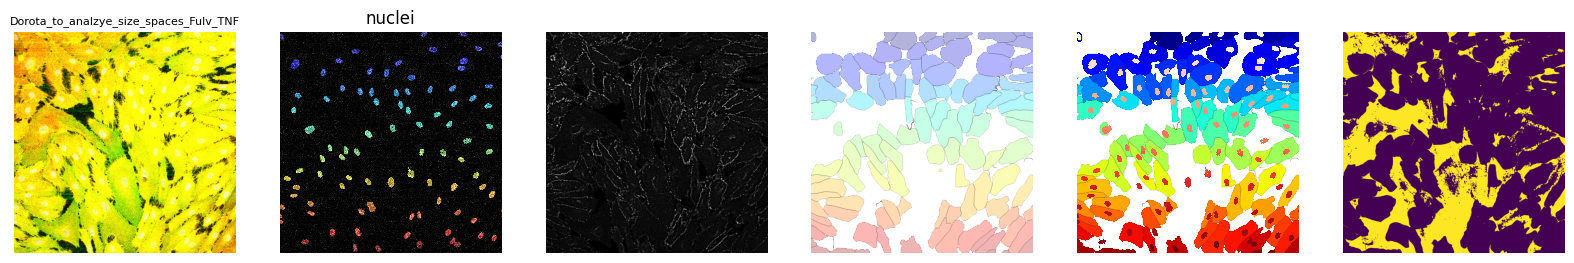

(10, 4, 2048, 2048)
Dorota_to_analzye_size_spaces_Fulv_E2P4_TNF (10, 4, 2048, 2048) (1.9998566666666668, 0.283952125061065, 0.283952125061065)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


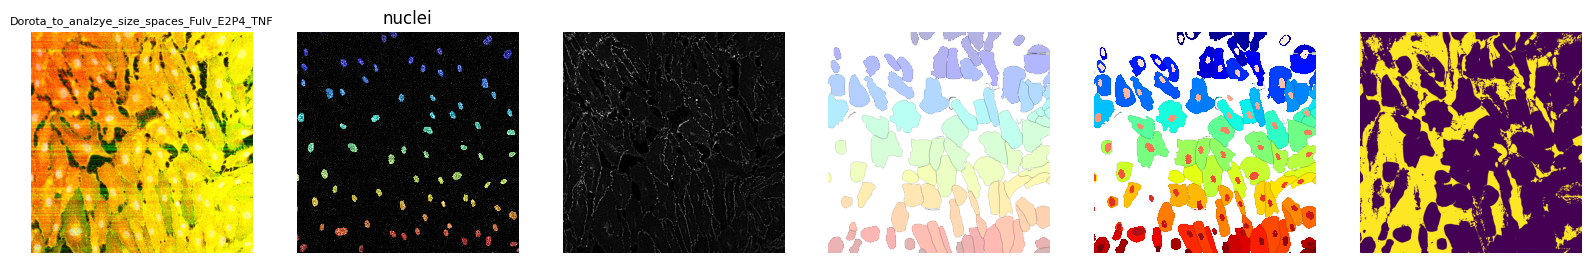

(7, 4, 2048, 2048)
Dorota_to_analzye_size_spaces_ctrl (7, 4, 2048, 2048) (1.9998566666666602, 0.283952125061065, 0.283952125061065)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


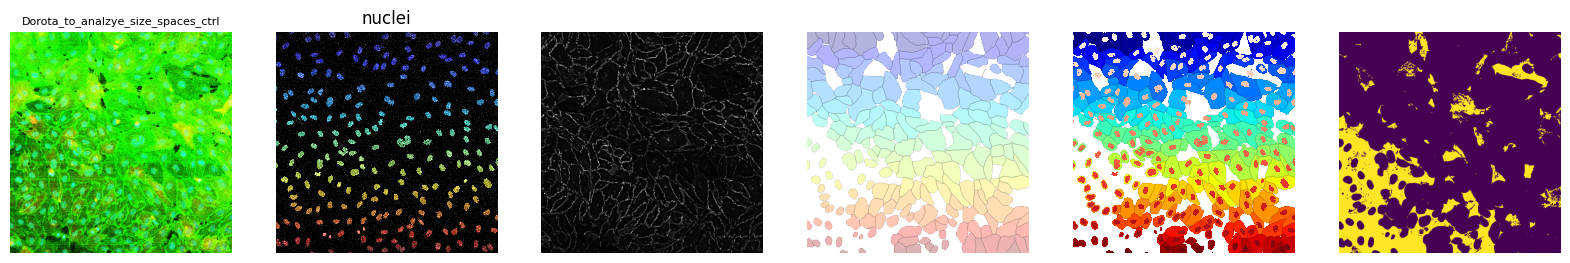

(9, 4, 2048, 2048)
Dorota_to_analzye_size_spaces_E2P4 (9, 4, 2048, 2048) (1.9998574999999945, 0.283952125061065, 0.283952125061065)


In [ ]:
input_dir = pathlib.Path(r"Z:\Bel\Dorota_Image_Analzsis_Size_Spaces")
output_dir = pathlib.Path(f"{str(input_dir)}\outputs")
output_dir.mkdir(parents=True, exist_ok=True)
dapi_channel = 0
membrane_channel = 2
protein_of_interest_channel = 1
protein_of_interest_2_channel = 3
all_props = segment_nuclei_and_quantify_protein(input_dir, output_dir, to_plot=True, dapi_channel=dapi_channel, membrane_channel=membrane_channel, protein_of_interest_1_channel=protein_of_interest_channel,protein_of_interest_2_channel=protein_of_interest_2_channel, max_proj=True)

# root= r"Z:\Chiara\Opera\TOMM20_20x_HUVEC\stitchresult"
# image_paths = list(pathlib.Path(root).glob("**/*.tiff"))
# output_dir = pathlib.Path(rf"{root}\python_outputs")
# output_dir.mkdir(parents=True, exist_ok=True)
# for i in [0,20,50]:
#     all_props = segment_nuclei_and_quantify_protein(image_paths, i, output_dir, max_proj=True, pixel_size=0.5897092, to_plot = True)


In [ ]:
all_props

""


In [ ]:
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    output = Parallel(n_jobs=4)(delayed(segment_nuclei_and_quantify_protein)(image_paths, i, output_dir, max_proj=True, pixel_size=0.5897092, to_plot = True) for i in range(len(image_paths)))
total_area = pd.concat(output)
total_area.to_csv(rf"{output_dir}\tomm20_localisation.csv")


NameError: name 'image_paths' is not defined

In [ ]:
total_area.head()

,label,cell_area_pixel,nuclear_area_pixel,filename,cell_type,treatment,timepoint,TOMM20_cell,TOMM20_nucleus,TOMM20_nucleus/cell,nuc/cell_area
0,12,2613.0,539.0,10PFOA_2_F1.ome.tiff,OTHER,10PFOA,0hr,54974,12766,0.232219,0.206276
1,18,4579.0,642.0,10PFOA_2_F1.ome.tiff,OTHER,10PFOA,0hr,107152,21184,0.197700,0.140205
2,19,4409.0,692.0,10PFOA_2_F1.ome.tiff,OTHER,10PFOA,0hr,101386,18390,0.181386,0.156952
3,21,3495.0,612.0,10PFOA_2_F1.ome.tiff,OTHER,10PFOA,0hr,72145,13280,0.184074,0.175107
4,22,6869.0,867.0,10PFOA_2_F1.ome.tiff,OTHER,10PFOA,0hr,155783,25131,0.161321,0.126219


<Axes: xlabel='treatment', ylabel='TOMM20_cell'>

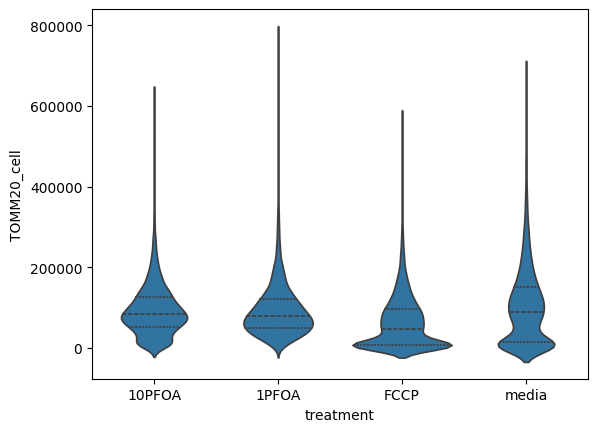

In [ ]:
sns.violinplot(data = total_area, x="treatment", y="TOMM20_cell", inner = "quartile")

In [ ]:
data = pd.read_csv("yap_localisation.csv")

In [ ]:
my_cols = ["red", "dodgerblue", "limegreen"]

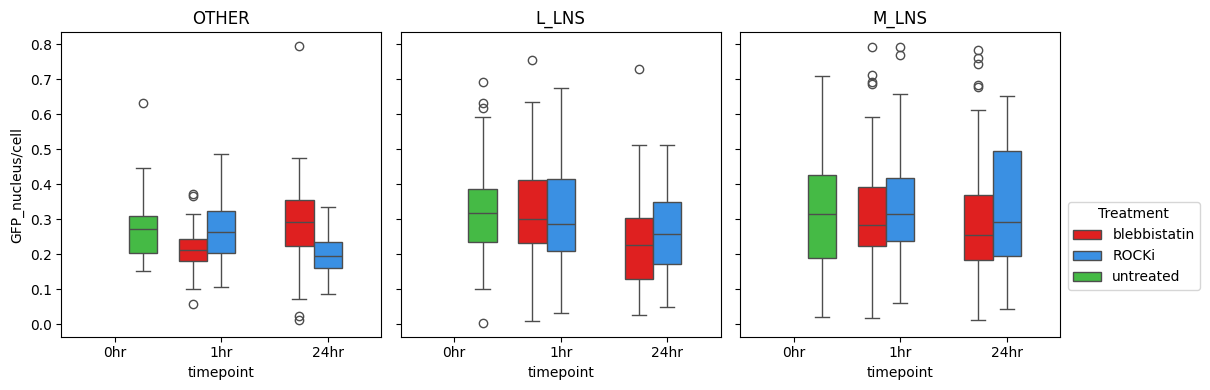

In [ ]:
fix, ax = plt.subplots(ncols=3, figsize=(12, 4), sharey=True)

for i, cell_type in enumerate(data["cell_type"].unique()):
    sns.boxplot(
        data=data[data["cell_type"] == cell_type],
        x="timepoint",
        y="GFP_nucleus/cell",
        hue="treatment",
        ax=ax[i],
        order=["0hr", "1hr", "24hr"],
        palette=my_cols
    )
    ax[i].set_title(cell_type)
    # Remove individual legends
    ax[i].get_legend().remove()

# Add one shared legend to the right
handles, labels = ax[0].get_legend_handles_labels()
fix.legend(handles, labels, title="Treatment", bbox_to_anchor=(1.01, 0.5))

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for legend
plt.show()


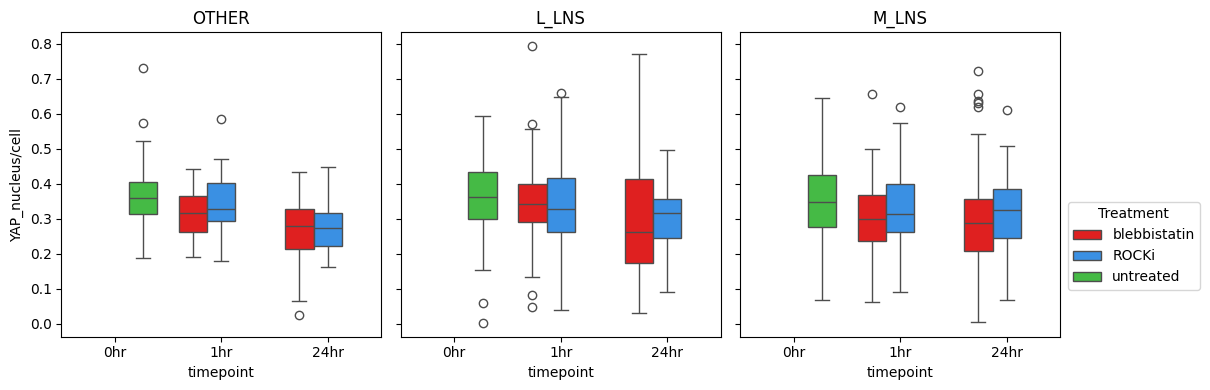

In [ ]:
fix, ax = plt.subplots(ncols=3, figsize=(12, 4), sharey=True)

for i, cell_type in enumerate(data["cell_type"].unique()):
    sns.boxplot(
        data=data[data["cell_type"] == cell_type],
        x="timepoint",
        y="YAP_nucleus/cell",
        hue="treatment",
        ax=ax[i],
        order=["0hr", "1hr", "24hr"],
        palette=my_cols
    )
    ax[i].set_title(cell_type)
    # Remove individual legends
    ax[i].get_legend().remove()

# Add one shared legend to the right
handles, labels = ax[0].get_legend_handles_labels()
fix.legend(handles, labels, title="Treatment", bbox_to_anchor=(1.01, 0.5))

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for legend
plt.show()